In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")

# Chargement des données générées par le Notebook 1
# On précise que la première colonne (l'id du client) doit redevenir l'index
features = pd.read_csv('/kaggle/input/datasets/victorchen004/datascience/features_pour_classification.csv', index_col='id')

print("Aperçu des données chargées :")
display(features.head())

Aperçu des données chargées :


,conso_moyenne,conso_std,ratio_we_semaine,ratio_hiver_ete,prop_conso_nulle,cluster,label
id,,,,,,,
476866365062,307.681339,406.669264,1.162697,1.266763,0.001030,3,0
47000903308,383.469036,408.919436,1.007164,2.844302,0.000286,7,0
980841892564,342.786035,453.591382,1.034510,3.041762,0.000000,10,0
917755392634,320.019840,342.744112,1.058378,3.322581,0.021463,4,0
834037955197,436.286161,505.522217,1.056283,3.562713,0.006124,2,0


In [5]:
# Nos variables explicatives (X) : on enlève 'label' et 'cluster'
X = features.drop(columns=['label', 'cluster'])

# Notre variable cible (y)
y = features['label']

# Séparation : 70% pour l'entraînement, 30% pour le test
# stratify=y permet de garder la même proportion de RS/RP dans le train et le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Normalisation des données (indispensable pour la Régression Logistique et les Réseaux de Neurones)
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

print(f"Dimensions du jeu d'entraînement : {X_train_scaled.shape}")
print(f"Dimensions du jeu de test : {X_test_scaled.shape}")

Dimensions du jeu d'entraînement : (350, 5)
Dimensions du jeu de test : (150, 5)


In [6]:
print("Entraînement des modèles en cours...")

# 1. Régression Logistique
# class_weight='balanced' aide le modèle à gérer le fait qu'il y a plus de RP que de RS
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

# 2. Forêt Aléatoire (Random Forest)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train_scaled, y_train) # Le Random forest peut utiliser les données scalées sans souci

# 3. Réseau de Neurones (Multi-Layer Perceptron)
# Un réseau avec deux couches cachées (64 puis 32 neurones)
mlp_clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp_clf.fit(X_train_scaled, y_train)

# 4. Support Vector Machine (SVM)
# On utilise un noyau 'rbf' (par défaut, excellent pour les relations non linéaires)
# et class_weight='balanced' pour gérer le déséquilibre RS/RP
svm_clf = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_clf.fit(X_train_scaled, y_train)

print("Entraînement terminé !")

Entraînement des modèles en cours...
Entraînement terminé !



--- Rapport de Régression Logistique ---
              precision    recall  f1-score   support

           0       0.97      0.86      0.91       116
           1       0.66      0.91      0.77        34

    accuracy                           0.87       150
   macro avg       0.82      0.89      0.84       150
weighted avg       0.90      0.87      0.88       150


--- Rapport de Random Forest ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       116
           1       0.97      0.88      0.92        34

    accuracy                           0.97       150
   macro avg       0.97      0.94      0.95       150
weighted avg       0.97      0.97      0.97       150


--- Rapport de Réseau de Neurones ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       116
           1       0.97      0.97      0.97        34

    accuracy                           0.99       150
   macro avg 

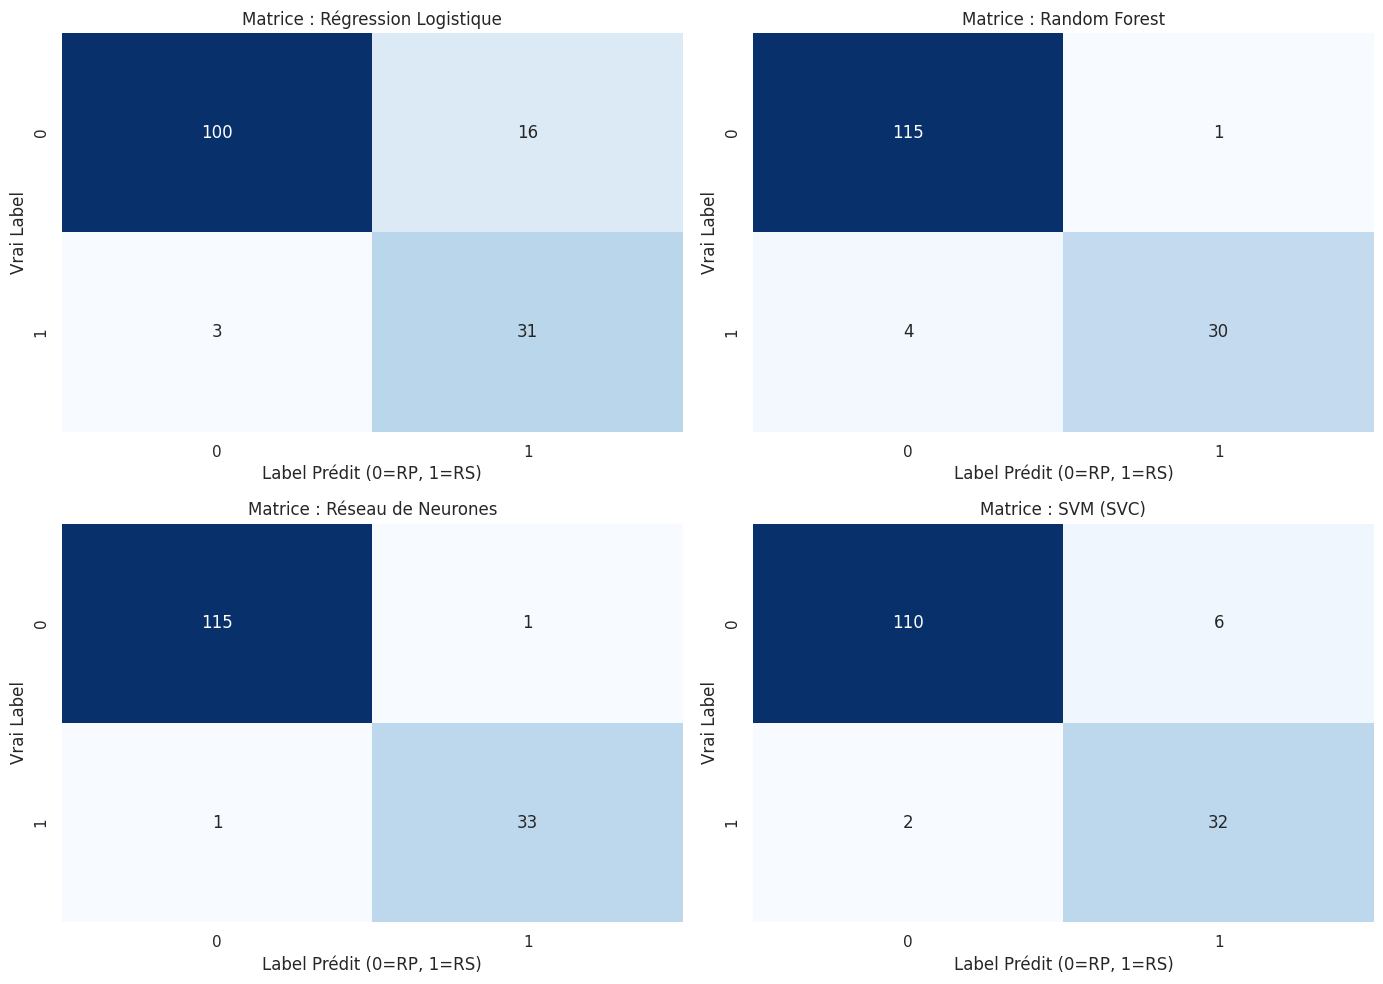

In [7]:
# Dictionnaire pour boucler sur nos modèles facilement
modeles = {
    "Régression Logistique": log_reg,
    "Random Forest": rf_clf,
    "Réseau de Neurones": mlp_clf,
    "SVM (SVC)": svm_clf
}

# Configuration d'une grille 2x2 pour 4 modèles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Permet de boucler plus facilement sur les 4 cases

for i, (nom, modele) in enumerate(modeles.items()):
    # Prédictions sur le jeu de test
    y_pred = modele.predict(X_test_scaled)
    
    # Affichage du rapport complet (précision, rappel, f1-score)
    print(f"\n--- Rapport de {nom} ---")
    print(classification_report(y_test, y_pred))
    
    # Création de la matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'Matrice : {nom}')
    axes[i].set_xlabel('Label Prédit (0=RP, 1=RS)')
    axes[i].set_ylabel('Vrai Label')

plt.tight_layout()
plt.show()

/tmp/ipykernel_55/108591639.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=df_importances, palette='viridis')


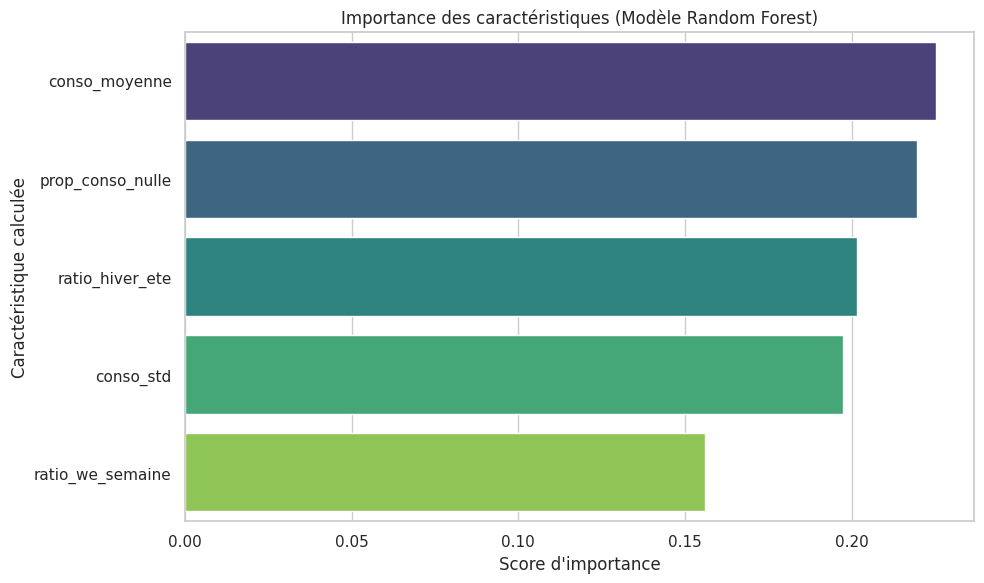

In [8]:
# Extraction de l'importance des variables depuis le Random Forest
importances = rf_clf.feature_importances_
noms_variables = X.columns

# Création d'un DataFrame pour l'affichage
df_importances = pd.DataFrame({
    'Variable': noms_variables,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Affichage graphique
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=df_importances, palette='viridis')
plt.title("Importance des caractéristiques (Modèle Random Forest)")
plt.xlabel("Score d'importance")
plt.ylabel("Caractéristique calculée")
plt.tight_layout()
plt.show()